<a href="https://colab.research.google.com/github/Ravi-ranjan1801/DIP-Lab/blob/main/dip_lab_06_Noise_Models%2C_PSNR_SSIM%2C_Restoration_Filters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lab 06**

In [27]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

### PART 1 — Synthetic Image + Noise + PSNR/SSIM

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

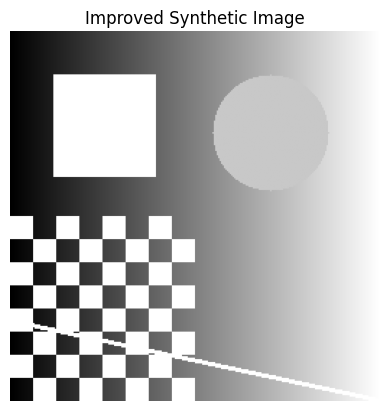

In [28]:
# Create synthetic image (edges + patterns + gradients)

img = np.zeros((256,256), dtype=np.uint8)
for i in range(256):
    img[:, i] = i

cv2.rectangle(img, (30,30), (100,100), 255, -1)
cv2.circle(img, (180,70), 40, 200, -1)
cv2.line(img, (0,200), (255,255), 255, 2)

for i in range(128,256,16):
    for j in range(0,128,16):
        if (i//16 + j//16) % 2 == 0:
            img[i:i+16, j:j+16] = 255

plt.imshow(img, cmap='gray')
plt.title("Improved Synthetic Image")
plt.axis('off')

In [29]:
#noise functions
def add_gaussian(img):
    noise = np.random.normal(0,25,img.shape)
    return np.clip(img + noise,0,255).astype(np.uint8)

def add_rayleigh(img):
    noise = np.random.rayleigh(20,img.shape)
    return np.clip(img + noise,0,255).astype(np.uint8)

def add_gamma(img):
    noise = np.random.gamma(2,10,img.shape)
    return np.clip(img + noise,0,255).astype(np.uint8)

def add_exponential(img):
    noise = np.random.exponential(20,img.shape)
    return np.clip(img + noise,0,255).astype(np.uint8)

def add_uniform(img):
    noise = np.random.uniform(-30,30,img.shape)
    return np.clip(img + noise,0,255).astype(np.uint8)

def add_salt_pepper(img):
    noisy = img.copy()
    prob = 0.02
    salt = np.random.rand(*img.shape) < prob
    pepper = np.random.rand(*img.shape) < prob
    noisy[salt] = 255
    noisy[pepper] = 0
    return noisy

Gaussian
PSNR: 21.09616562506404
SSIM: 0.297630114319517
Rayleigh
PSNR: 20.826148709771154
SSIM: 0.5617426692018344
Gamma
PSNR: 22.183330418150327
SSIM: 0.5505730430187947
Exponential
PSNR: 21.272328658238983
SSIM: 0.4907289812688086
Uniform
PSNR: 24.0716643630199
SSIM: 0.37868062167852623
Salt & Pepper
PSNR: 18.273934223940852
SSIM: 0.4151705080175174


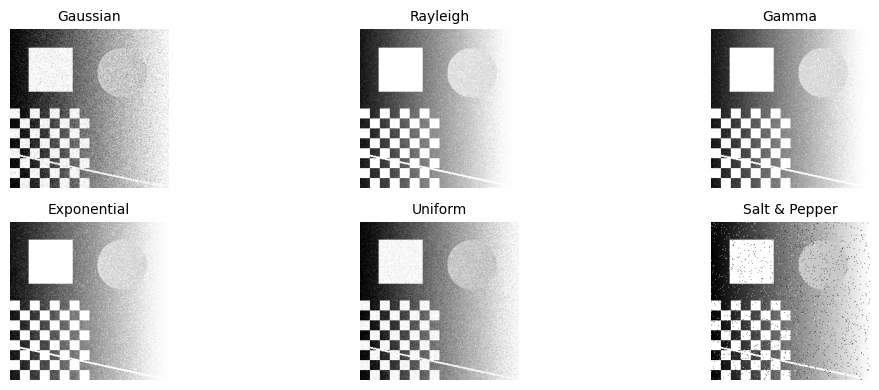

In [30]:
# apply noise + compare psnr ssim
noises = {
    "Gaussian": add_gaussian(img),
    "Rayleigh": add_rayleigh(img),
    "Gamma": add_gamma(img),
    "Exponential": add_exponential(img),
    "Uniform": add_uniform(img),
    "Salt & Pepper": add_salt_pepper(img)
}

# Print metrics
for name, noisy in noises.items():
    print(name)
    print("PSNR:", psnr(img, noisy))
    print("SSIM:", ssim(img, noisy, data_range=255))

# Display images (horizontal grid)
plt.figure(figsize=(12,4))

for i, (name, noisy) in enumerate(noises.items()):
    plt.subplot(2,3,i+1)
    plt.imshow(noisy, cmap='gray')
    plt.title(name, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

### PART 2 — Periodic Noise + Butterworth Band Reject

(np.float64(-0.5), np.float64(799.5), np.float64(556.5), np.float64(-0.5))

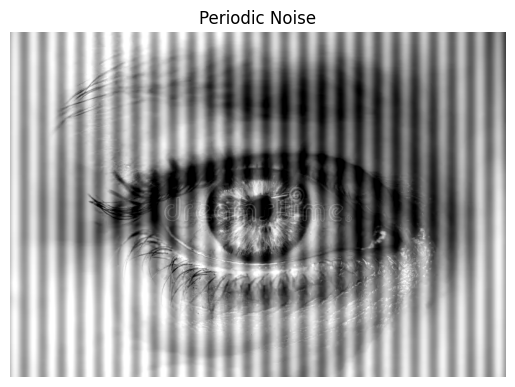

In [31]:
#add periodic noise
img = cv2.imread('image.webp',0)
rows, cols = img.shape

x = np.arange(cols)
y = np.arange(rows)
x,y = np.meshgrid(x,y)

periodic = 50*np.sin(2*np.pi*x/30)

noisy = np.clip(img + periodic,0,255).astype(np.uint8)

plt.imshow(noisy, cmap='gray')
plt.title("Periodic Noise")
plt.axis('off')

In [32]:
# Butterworth band reject filter
def butterworth_brf(shape, d0, w, n):

    rows, cols = shape
    crow, ccol = rows//2, cols//2
    H = np.zeros((rows,cols))

    for i in range(rows):
        for j in range(cols):
            D = np.sqrt((i-crow)**2 + (j-ccol)**2)

            if D == 0:
                H[i,j] = 0
            else:
                H[i,j] = 1 / (1 + ((D*w)/(D**2 - d0**2))**(2*n))


    return H

/tmp/ipykernel_7403/1075465169.py:15: RuntimeWarning: divide by zero encountered in scalar divide
  H[i,j] = 1 / (1 + ((D*w)/(D**2 - d0**2))**(2*n))


Noisy PSNR: 17.24836780361714
Filtered PSNR: 6.481111494925171
Noisy SSIM: 0.39900765136139366
Filtered SSIM: 0.21626185787844285


/tmp/ipykernel_7403/1005008534.py:12: UserWarning: Inputs have mismatched dtype.  Setting data_range based on image_true.
  print("Filtered PSNR:", psnr(img,img_back))


(np.float64(-0.5), np.float64(799.5), np.float64(556.5), np.float64(-0.5))

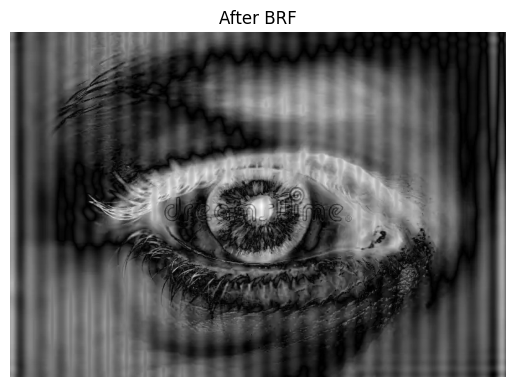

In [33]:
#apply BRF + compare
f = np.fft.fft2(noisy)
fshift = np.fft.fftshift(f)

H = butterworth_brf(img.shape,30,10,2)

filtered = fshift * H

img_back = np.abs(np.fft.ifft2(np.fft.ifftshift(filtered)))

print("Noisy PSNR:", psnr(img,noisy))
print("Filtered PSNR:", psnr(img,img_back))

print("Noisy SSIM:", ssim(img,noisy))
print("Filtered SSIM:", ssim(img, img_back, data_range=255))

plt.imshow(img_back, cmap='gray')
plt.title("After BRF")
plt.axis('off')

### PART 3 — Gaussian Noise + Mean Filters

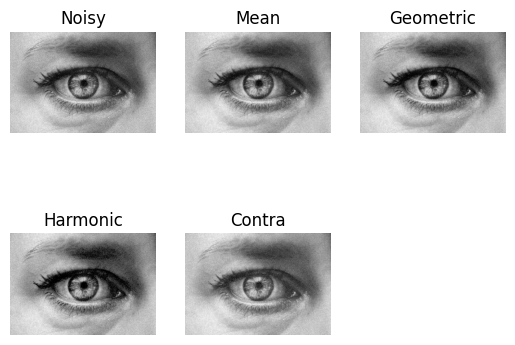

In [34]:
img = cv2.imread('image.webp',0)
noisy = add_gaussian(img)
mean = cv2.blur(noisy,(3,3)) #AM filter

def geometric_filter(img):   #GM filer
    img = img.astype(np.float32)+1
    log = np.log(img)
    mean = cv2.blur(log,(3,3))
    return np.exp(mean)-1

geo = geometric_filter(noisy)

def harmonic_filter(img):  #HM filter
    img = img.astype(np.float32)+1
    inv = 1/img
    mean = cv2.blur(inv,(3,3))
    return 1/mean

harm = harmonic_filter(noisy)

def contra_filter(img, Q=1.5): #CHM filter
    img = img.astype(np.float32)+1
    num = cv2.blur(img**(Q+1),(3,3))
    den = cv2.blur(img**Q,(3,3))
    return num/den

contra = contra_filter(noisy)

titles = ["Noisy","Mean","Geometric","Harmonic","Contra"]

images = [noisy, mean, geo, harm, contra]

for i in range(5):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.show()

### PART 4 — Salt & Pepper + Nonlinear Filters

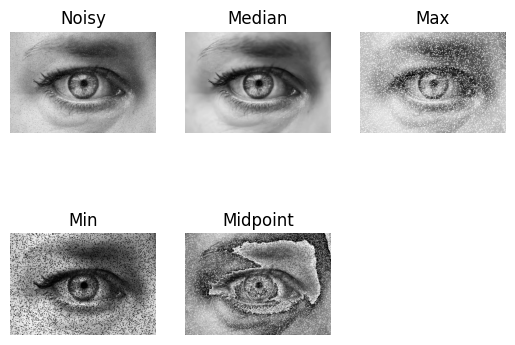

In [35]:
noisy = add_salt_pepper(img)
median = cv2.medianBlur(noisy,3)
maxf = cv2.dilate(noisy, np.ones((3,3)))
minf = cv2.erode(noisy, np.ones((3,3)))
mid = (maxf + minf) / 2

titles = ["Noisy","Median","Max","Min","Midpoint"]
images = [noisy, median, maxf, minf, mid]

for i in range(5):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.show()